# Step 14. The figures, two tier

Reads `step12_panels.rds` and `step13_clusters.rds`. Writes the PNGs and `step14_zoom_depth.rds`.

The k-means arm is drawn separately, in step 15.

Panels are 490–863 probes, so per-protein labels are not legible at full width. Rather than
silently subsetting:

- Tier 1, overview, the whole panel, both dendrograms, no protein labels. Row dendrogram and
  row names share the left side; column dendrogram and column names share the top.
- Tier 2, labelled zooms, descend the column dendrogram until every cluster fits the label
  budget, then draw one labelled heatmap per cluster, and report how many levels that took.

`MAX_LABELS = 80` is a rendering limit, not a statistical one, and is stated as such.

One trap, documented in `src/final_matrix.R`: with `column_split` set, `Heatmap()`'s `column_title`
becomes the per-slice title. Figure captions go on `draw()`.

In [1]:
suppressMessages({library(ComplexHeatmap); library(circlize); library(grid)})
source("../src/paths.R")
options(stringsAsFactors = FALSE); set.seed(42)
P <- readRDS(art("step12_panels.rds")); K <- readRDS(art("step13_clusters.rds"))
D <- P$D; spec <- P$spec; MINK_P <- P$MINK_P; LINK <- P$LINK; SITES <- P$SITES
RES <- K$RES
W <- lapply(SITES, function(s) readRDS(art("wgcna_%s.rds", s))); names(W) <- SITES

MAX_LABELS <- 80      # a RENDERING limit, not a statistical one

suppressMessages({library(ComplexHeatmap);library(circlize);library(grid)})
dmink <- function(m) dist(m, method="minkowski", p=MINK_P)

# ── shared trait colours ──────────────────────────────────────────────────
# Every panel MUST use the same mapping, or a legend is a lie and the cohorts
# cannot be compared by eye. A fresh rowAnnotation() per panel gets its own
# palette, so the maps are built once here, over the pooled range of all three
# cohorts, and passed to every panel.
#
# Hue carries the antigen/organ system from the `group` column of
# cohorts/clinical-traits.csv, so traits that belong together read together.
GROUP_HUE <- c(activity = "#B2182B", complement = "#2166AC", history = "#5B5B5B",
               haematology = "#1B7837", renal = "#762A83", demographic = "#E08214",
               snRNP = "#B2182B", RoLa = "#B2182B", dsDNA = "#B2182B")
BINARY_COL <- c(Negative = "#F0F0F0", Borderline = "#FDB863", Positive = "#B2182B")

build_trait_colours <- function(spec, metas) {
  out <- list()
  for (i in seq_len(nrow(spec))) {
    src <- spec$source_column[i]
    v   <- unlist(lapply(metas, function(m) m[[src]]))
    hue <- GROUP_HUE[[spec$group[i]]]
    if (spec$type[i] == "numeric") {
      # 5th-95th percentile, not min-max: uPCR runs 0-1286 and a single outlier
      # would flatten every other patient to the same colour.
      qs <- quantile(as.numeric(v), c(.05, .95), na.rm = TRUE)
      if (diff(qs) == 0) qs <- range(as.numeric(v), na.rm = TRUE)
      out[[src]] <- colorRamp2(c(qs[1], qs[2]), c("#FFFFFF", hue))
    } else if (spec$type[i] == "binary") {
      out[[src]] <- BINARY_COL[intersect(names(BINARY_COL), unique(as.character(v)))]
    } else {                                   # ordinal: the age bands, in order
      lv <- sort(unique(as.character(v[!is.na(v) & v != ""])))
      lv <- lv[order(as.numeric(sub("-.*", "", lv)))]
      out[[src]] <- setNames(colorRampPalette(c("#FFFFFF", hue))(length(lv)), lv)
    }
  }
  out
}
TRAIT_COLS <- build_trait_colours(spec, lapply(W, `[[`, "meta"))

# show_leg: the trait legend is drawn on ONE panel per figure, not all three.
trait_annotation <- function(s, rn, traits, show_leg = FALSE) {
  df <- ann_of(s, rn, traits)
  rowAnnotation(df = df, col = TRAIT_COLS[names(df)],
                annotation_name_gp = gpar(fontsize = 5), show_legend = show_leg,
                annotation_legend_param = list(labels_gp = gpar(fontsize = 6),
                                               title_gp  = gpar(fontsize = 7),
                                               grid_height = unit(2.5, "mm"),
                                               grid_width  = unit(2.5, "mm")))
}

# A standalone legend, built from the SAME TRAIT_COLS object the panels use, so
# it cannot drift from what is drawn. The 2x3 arms figure has no room for 15
# stacked legends, and a clipped legend is worse than none.
trait_legend_figure <- function() {
  lgds <- lapply(seq_len(nrow(spec)), function(i) {
    src <- spec$source_column[i]; cm <- TRAIT_COLS[[src]]
    ttl <- sprintf("%s  (%s)", spec$name[i], spec$group[i])
    if (is.function(cm))
      Legend(col_fun = cm, title = ttl, title_gp = gpar(fontsize = 8, fontface = "bold"),
             labels_gp = gpar(fontsize = 7), legend_height = unit(22, "mm"))
    else
      Legend(at = names(cm), legend_gp = gpar(fill = unname(cm)), title = ttl,
             title_gp = gpar(fontsize = 8, fontface = "bold"),
             labels_gp = gpar(fontsize = 7),
             grid_height = unit(4, "mm"), grid_width = unit(4, "mm"))
  })
  # max_height is what makes packLegend wrap into columns; ncol alone stacks.
  packLegend(list = lgds, direction = "vertical", max_height = unit(15, "cm"),
             row_gap = unit(4, "mm"), column_gap = unit(10, "mm"))
}
png(art("fig14_trait_legend.png"), width = 2600, height = 1200, res = 170)
grid.newpage(); draw(trait_legend_figure())
invisible(dev.off())
cat("wrote", basename(art("fig14_trait_legend.png")),
    "-- one legend, shared by every panel in this notebook\n")

ann_of <- function(s, rn, traits){
  m <- W[[s]]$meta[rn, , drop=FALSE]
  cols <- intersect(spec$source_column[match(traits, spec$name)], names(m))
  m[, cols, drop=FALSE]
}

# ---- TIER 1: overview, no protein labels, both dendrograms, names on same side
tier1 <- function(nm, level=2, show_leg=FALSE){          # level 2 -> the 4-group cut
  r <- RES[[nm]]; d <- r$d; Z <- r$Z
  K <- 2^level                           # split IS the dendrogram cut, so pass k
  Heatmap(Z, name="z-score", col=colorRamp2(c(-2,0,2),c("#2166AC","white","#B2182B")),
    row_split=K, column_split=K,
    cluster_rows=r$hclust$hr, cluster_columns=r$hclust$hc,
    cluster_row_slices=FALSE, cluster_column_slices=FALSE,
    show_row_dend=TRUE,  row_dend_side="left",  row_dend_width=unit(14,"mm"),
    show_row_names=TRUE, row_names_side="left", row_names_gp=gpar(fontsize=3),
    show_column_dend=TRUE, column_dend_side="top", column_dend_height=unit(14,"mm"),
    show_column_names=FALSE,
    row_title_gp=gpar(fontsize=8), column_title_gp=gpar(fontsize=8),
    left_annotation=trait_annotation(d$cohort, rownames(Z), d$traits, show_leg),
    heatmap_legend_param=list(labels_gp=gpar(fontsize=7), title_gp=gpar(fontsize=8)))
}
for (cond in c("all15","varsel","union")){
  nms <- paste(SITES, cond)
  nms <- nms[nms %in% names(RES)]          # cohort B has no panel at the 1% cut
  png(art("fig14_hclust_wardD2_minkowski_%s.png", cond), width=3600, height=1700, res=150)
  grid.newpage(); pushViewport(viewport(layout=grid.layout(1,3)))
  for (i in seq_along(nms)){
    pushViewport(viewport(layout.pos.row=1, layout.pos.col=i))
    d <- D[[nms[i]]]
    draw(tier1(nms[i], show_leg = (i == length(nms))), newpage=FALSE,
      column_title=sprintf("cohort %s -- %s: %d modules, %s", d$cohort, cond,
                           length(d$keep), size_str(d$sel)),
      column_title_gp=gpar(fontsize=10, fontface="bold"))
    popViewport()
  }
  popViewport(); invisible(dev.off())
  cat("wrote", basename(art("fig14_hclust_wardD2_minkowski_%s.png", cond)), "\n")
}

# ---- TIER 2: descend the column dendrogram until clusters fit MAX_LABELS
depth_for <- function(hc, n, maxlab){
  for (lev in 1:8){ k <- 2^lev
    if (k > n) return(list(level=lev, k=n))
    if (max(table(cutree(hc,k))) <= maxlab) return(list(level=lev, k=k)) }
  list(level=8, k=256)
}
zoom_report <- NULL
for (s in SITES){
  nm <- paste(s,"all15"); if (!nm %in% names(RES)) next
  r <- RES[[nm]]; Z <- r$Z
  dd <- depth_for(r$hclust$hc, ncol(Z), MAX_LABELS)
  cl <- cutree(r$hclust$hc, dd$k)
  zoom_report <- rbind(zoom_report, data.frame(cohort=s, panel=ncol(Z),
    levels_down=dd$level, clusters=dd$k, largest=max(table(cl))))
  ord <- order(table(cl), decreasing=TRUE)
  keep <- as.integer(names(sort(table(cl), decreasing=TRUE)))[1:min(6,dd$k)]
  png(art("fig14_hclust_zoom_%s.png", s), width=3400, height=2000, res=150)
  grid.newpage(); pushViewport(viewport(layout=grid.layout(2,3)))
  for (i in seq_along(keep)){
    g <- names(cl)[cl==keep[i]]
    pushViewport(viewport(layout.pos.row=(i-1)%/%3+1, layout.pos.col=(i-1)%%3+1))
    ht <- Heatmap(Z[,g,drop=FALSE], name="z-score",
      col=colorRamp2(c(-2,0,2),c("#2166AC","white","#B2182B")),
      row_split=4, cluster_rows=r$hclust$hr, cluster_row_slices=FALSE,
      cluster_columns=TRUE, clustering_distance_columns=dmink, clustering_method_columns=LINK,
      show_row_dend=TRUE, row_dend_side="left", row_dend_width=unit(8,"mm"),
      show_row_names=FALSE,
      show_column_dend=TRUE, column_dend_side="top", column_dend_height=unit(12,"mm"),
      show_column_names=TRUE, column_names_side="top", column_names_gp=gpar(fontsize=5),
      row_title_gp=gpar(fontsize=7), show_heatmap_legend=(i==1),
      heatmap_legend_param=list(labels_gp=gpar(fontsize=6), title_gp=gpar(fontsize=7)))
    draw(ht, newpage=FALSE, column_title=sprintf("%s cluster %d -- %s", s, keep[i], size_str(g)),
         column_title_gp=gpar(fontsize=9, fontface="bold"))
    popViewport()
  }
  popViewport(); invisible(dev.off())
  cat("wrote", basename(art("fig14_hclust_zoom_%s.png", s)), "\n")
}
cat("\nlabelled-zoom depth (limit", MAX_LABELS, "proteins per panel):\n")
print(zoom_report, row.names=FALSE)

saveRDS(zoom_report, art("step14_zoom_depth.rds"))


wrote fig14_trait_legend.png -- one legend, shared by every panel in this notebook


wrote fig14_hclust_wardD2_minkowski_all15.png 


wrote fig14_hclust_wardD2_minkowski_varsel.png 


wrote fig14_hclust_wardD2_minkowski_union.png 


wrote fig14_hclust_zoom_A.png 


wrote fig14_hclust_zoom_C.png 



labelled-zoom depth (limit 80 proteins per panel):


 cohort panel levels_down clusters largest
      A   164           2        4      59
      C   119           1        2      63


At the 1% panel width the zoom is shallow: two levels in A (164 probes) and one in C
(119). A 4-way cut, one level then one more, leaves roughly 190 proteins per panel, so the analysis cut and the
legible cut are different depths, and both are produced.

## The final heatmap

Everything above is diagnostic. This is the figure the analysis has been building toward: the
panel at k = 8 on both axes, ward.D2 on Minkowski distance, patients and proteins both split,
every protein labelled, and each protein block annotated with the weighted gene co-expression network analysis (WGCNA) module a free clustering
recovered there.

At the 1% panel width this works. At the 10% width an earlier version used, it does not, the
protein clusters never matched a module (best Jaccard 0.14), so there was nothing to annotate.
Step 12's threshold scan is the evidence.

In [2]:
FINAL_K <- 8
jaccard <- function(a, b) length(intersect(a, b)) / length(union(a, b))

for (s in SITES) {
  nm <- paste(s, "all15"); if (!nm %in% names(RES)) next
  r <- RES[[nm]]; Z <- r$Z; d <- r$d
  cl <- cutree(r$hclust$hc, FINAL_K)

  # name each protein block by the module a free cluster reproduces there
  lab <- sapply(sort(unique(cl)), function(j) {
    g <- names(cl)[cl == j]
    bj <- sapply(setdiff(unique(r$mods), "grey"),
                 function(m) jaccard(g, names(r$mods)[r$mods == m]))
    if (max(bj) >= 0.99) names(bj)[which.max(bj)]
    else sprintf("M%d (best %s %.2f)", j, names(bj)[which.max(bj)], max(bj))
  })
  colsplit <- factor(lab[cl], levels = lab)

  png(art("fig14_final_heatmap_%s.png", s), width = 3000, height = 2000, res = 160)
  draw(Heatmap(Z, name = "z-score",
    col = colorRamp2(c(-2,0,2), c("#2166AC","white","#B2182B")),
    row_split = FINAL_K, column_split = colsplit,
    # rows keep the global dendrogram (a numeric split cuts it); columns are
    # split by NAME, which ComplexHeatmap will not accept alongside a dendrogram
    # object, so their trees are rebuilt per slice with the same distance and
    # linkage. Same geometry, named blocks.
    cluster_rows = r$hclust$hr,
    cluster_columns = TRUE,
    clustering_distance_columns = dmink, clustering_method_columns = LINK,
    cluster_row_slices = FALSE, cluster_column_slices = FALSE,
    show_row_dend = TRUE,  row_dend_side = "left", row_dend_width = unit(18, "mm"),
    show_row_names = TRUE, row_names_side = "left", row_names_gp = gpar(fontsize = 4),
    show_column_dend = TRUE, column_dend_side = "top", column_dend_height = unit(18, "mm"),
    show_column_names = TRUE, column_names_side = "bottom",
    column_names_gp = gpar(fontsize = 4),
    column_title_gp = gpar(fontsize = 8, fontface = "bold"), column_title_rot = 90,
    row_title_gp = gpar(fontsize = 9),
    left_annotation = trait_annotation(s, rownames(Z), d$traits, TRUE),
    heatmap_legend_param = list(labels_gp = gpar(fontsize = 7), title_gp = gpar(fontsize = 8))),
    column_title = sprintf("cohort %s -- final: k = %d both axes, ward.D2 / minkowski p = %d, %s",
                           s, FINAL_K, MINK_P, size_str(d$sel)),
    column_title_gp = gpar(fontsize = 12, fontface = "bold"))
  invisible(dev.off())
  cat(sprintf("wrote %s  -- %d of %d modules recovered exactly\n",
              basename(art("fig14_final_heatmap_%s.png", s)),
              sum(!grepl("^M[0-9]", lab)), length(setdiff(unique(r$mods), "grey"))))
}

wrote fig14_final_heatmap_A.png  -- 6 of 8 modules recovered exactly


wrote fig14_final_heatmap_C.png  -- 0 of 3 modules recovered exactly


## Figures

Written to `data/run_artifacts/`: the hierarchical heatmaps, labelled zooms, trait legend and final heatmap.


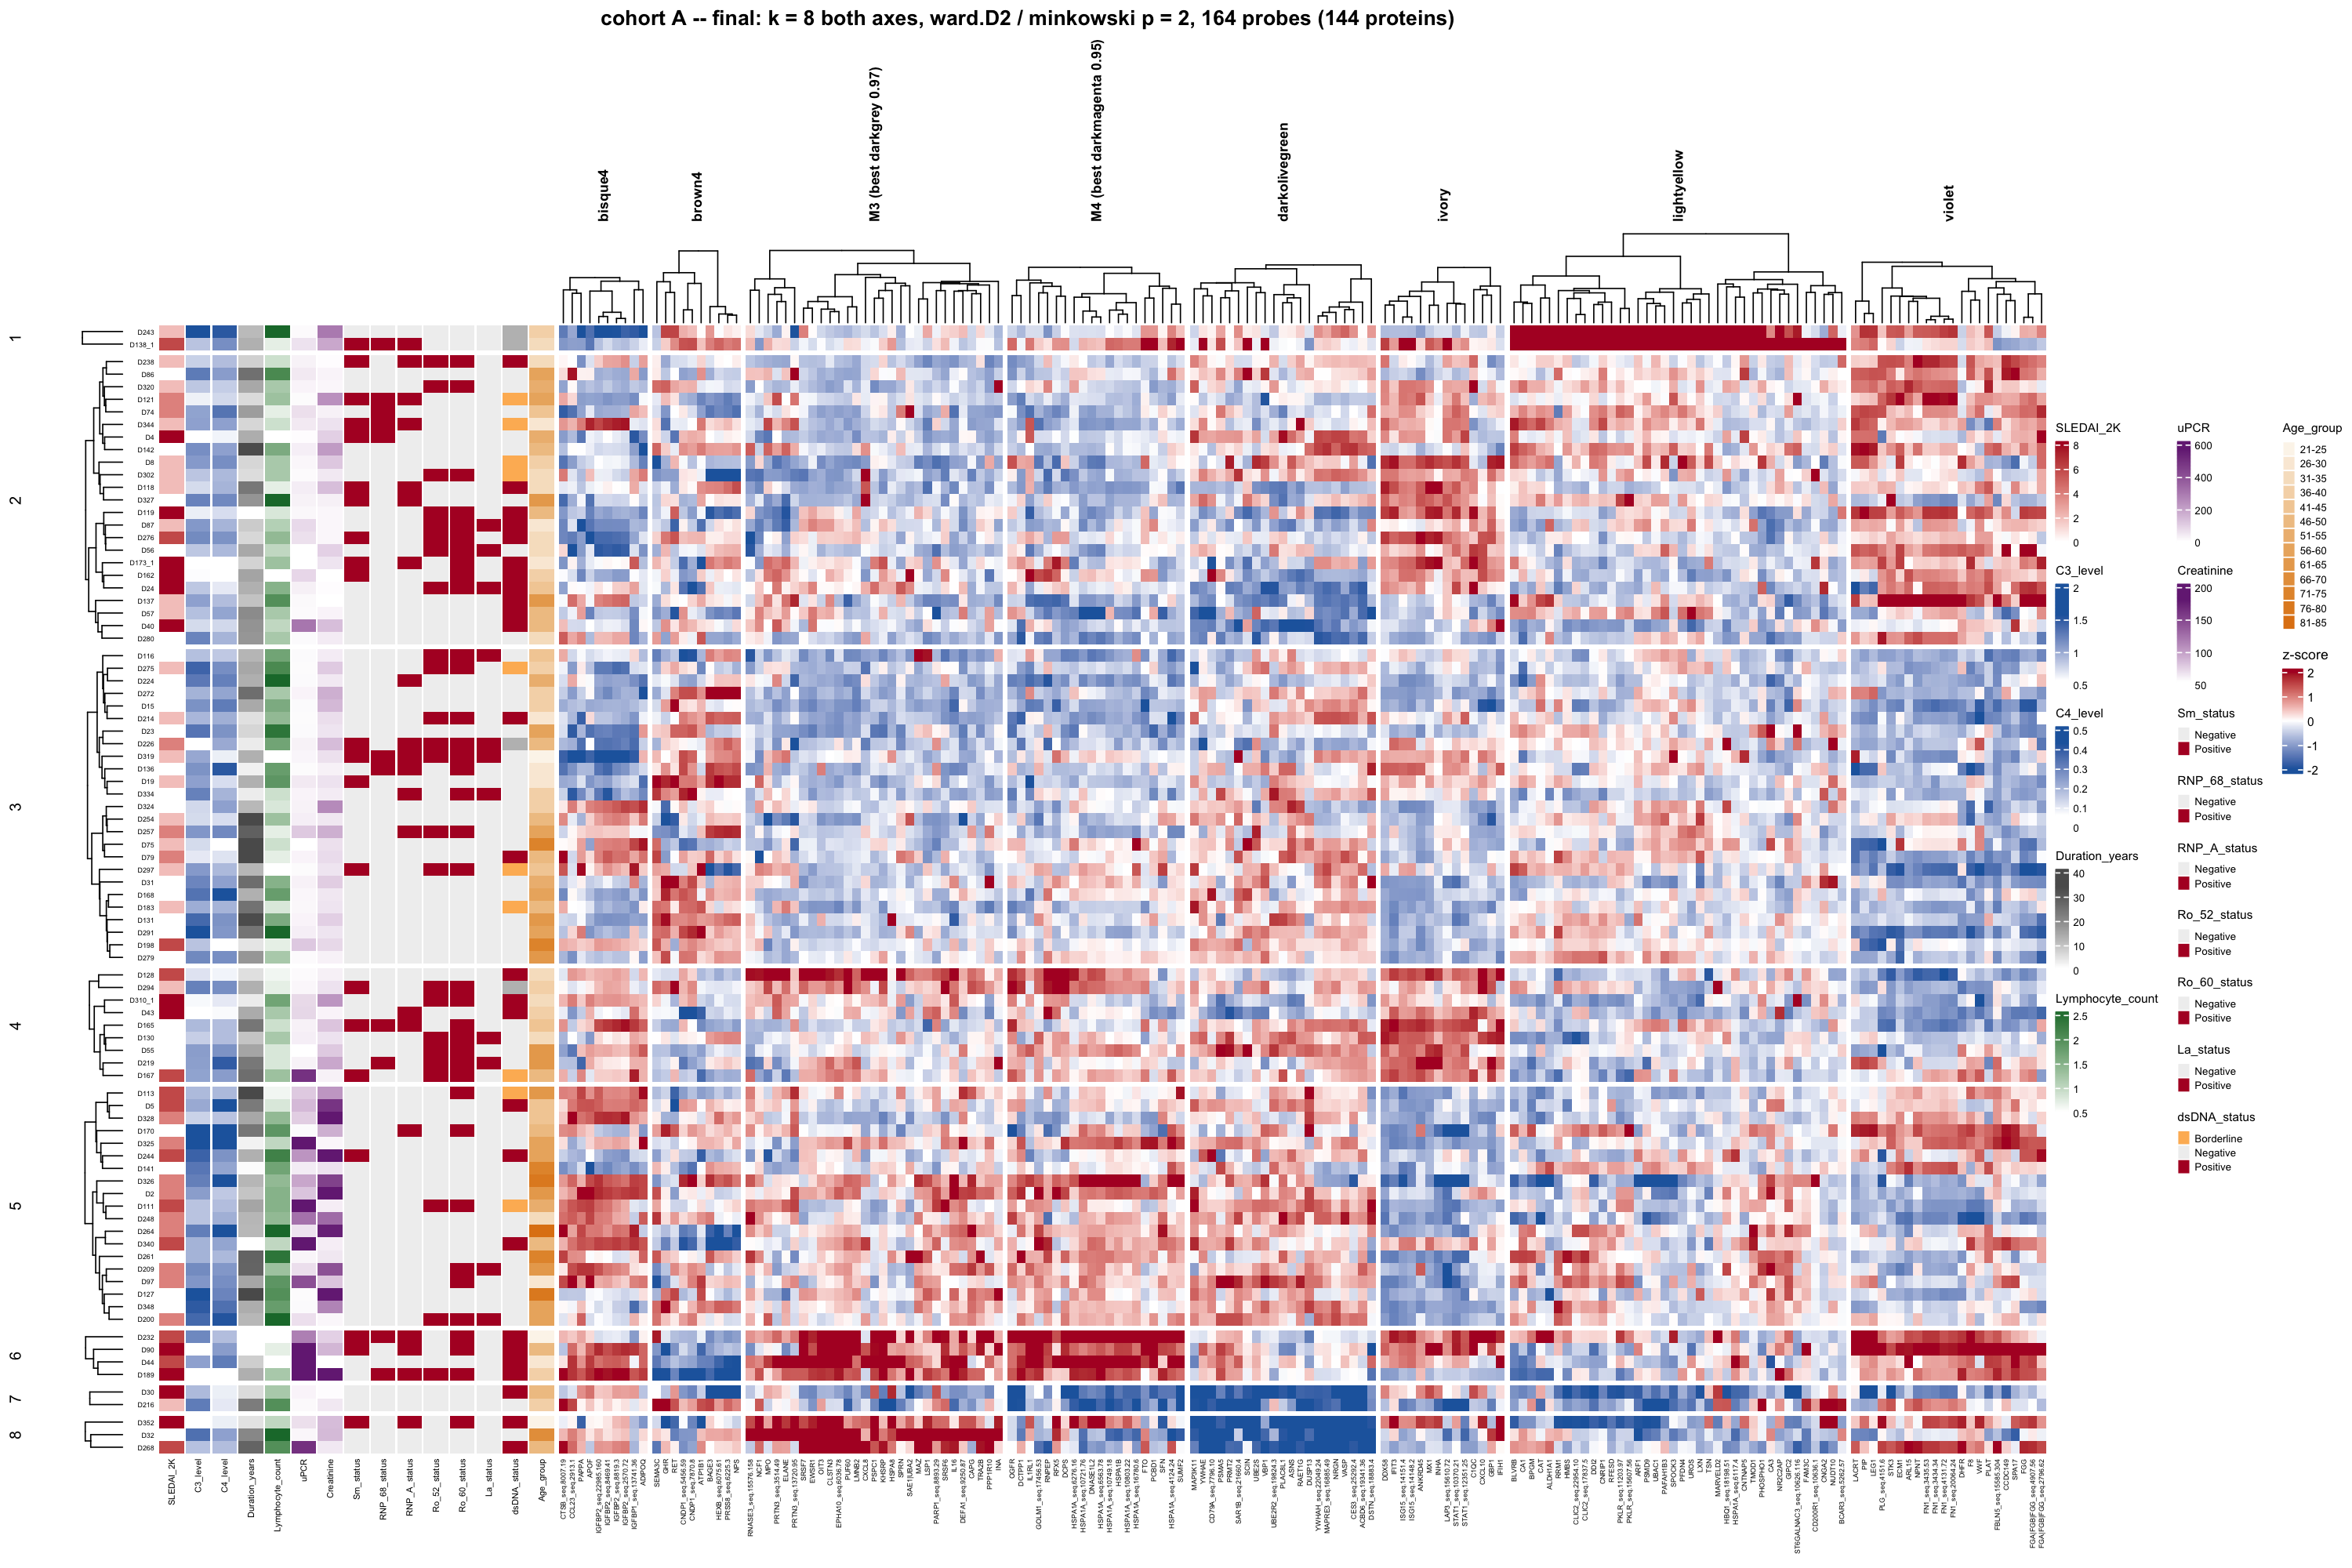

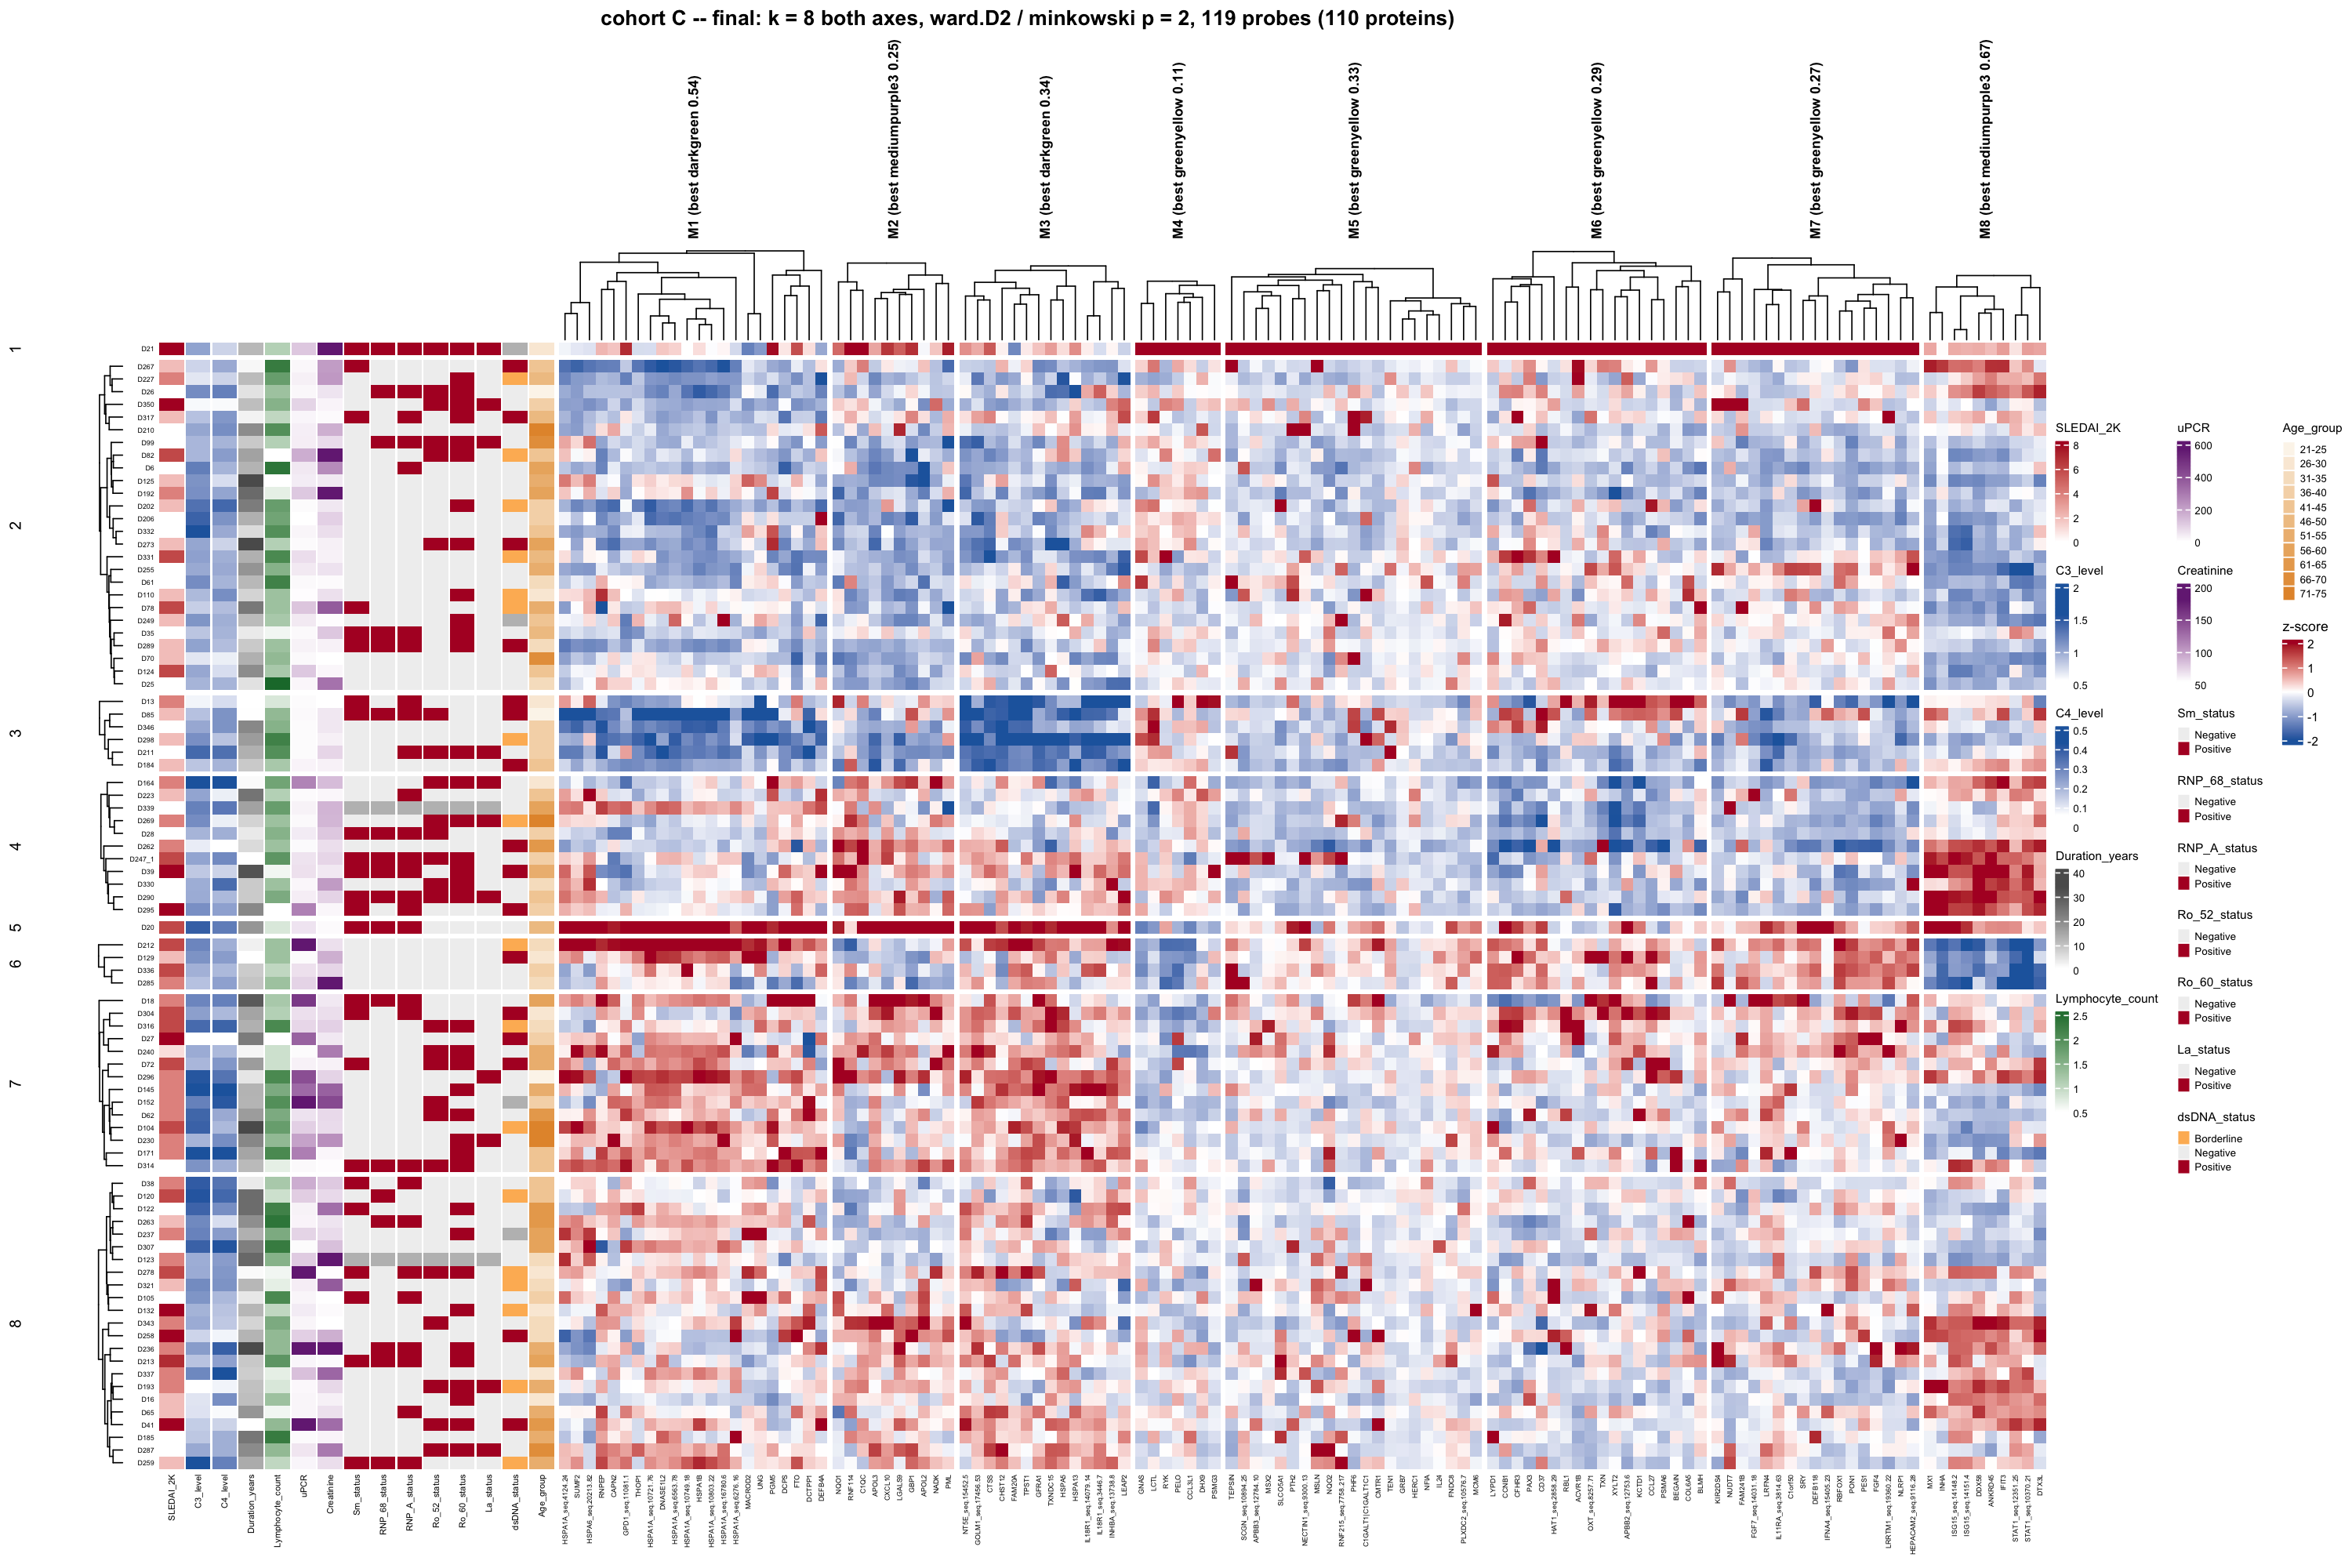

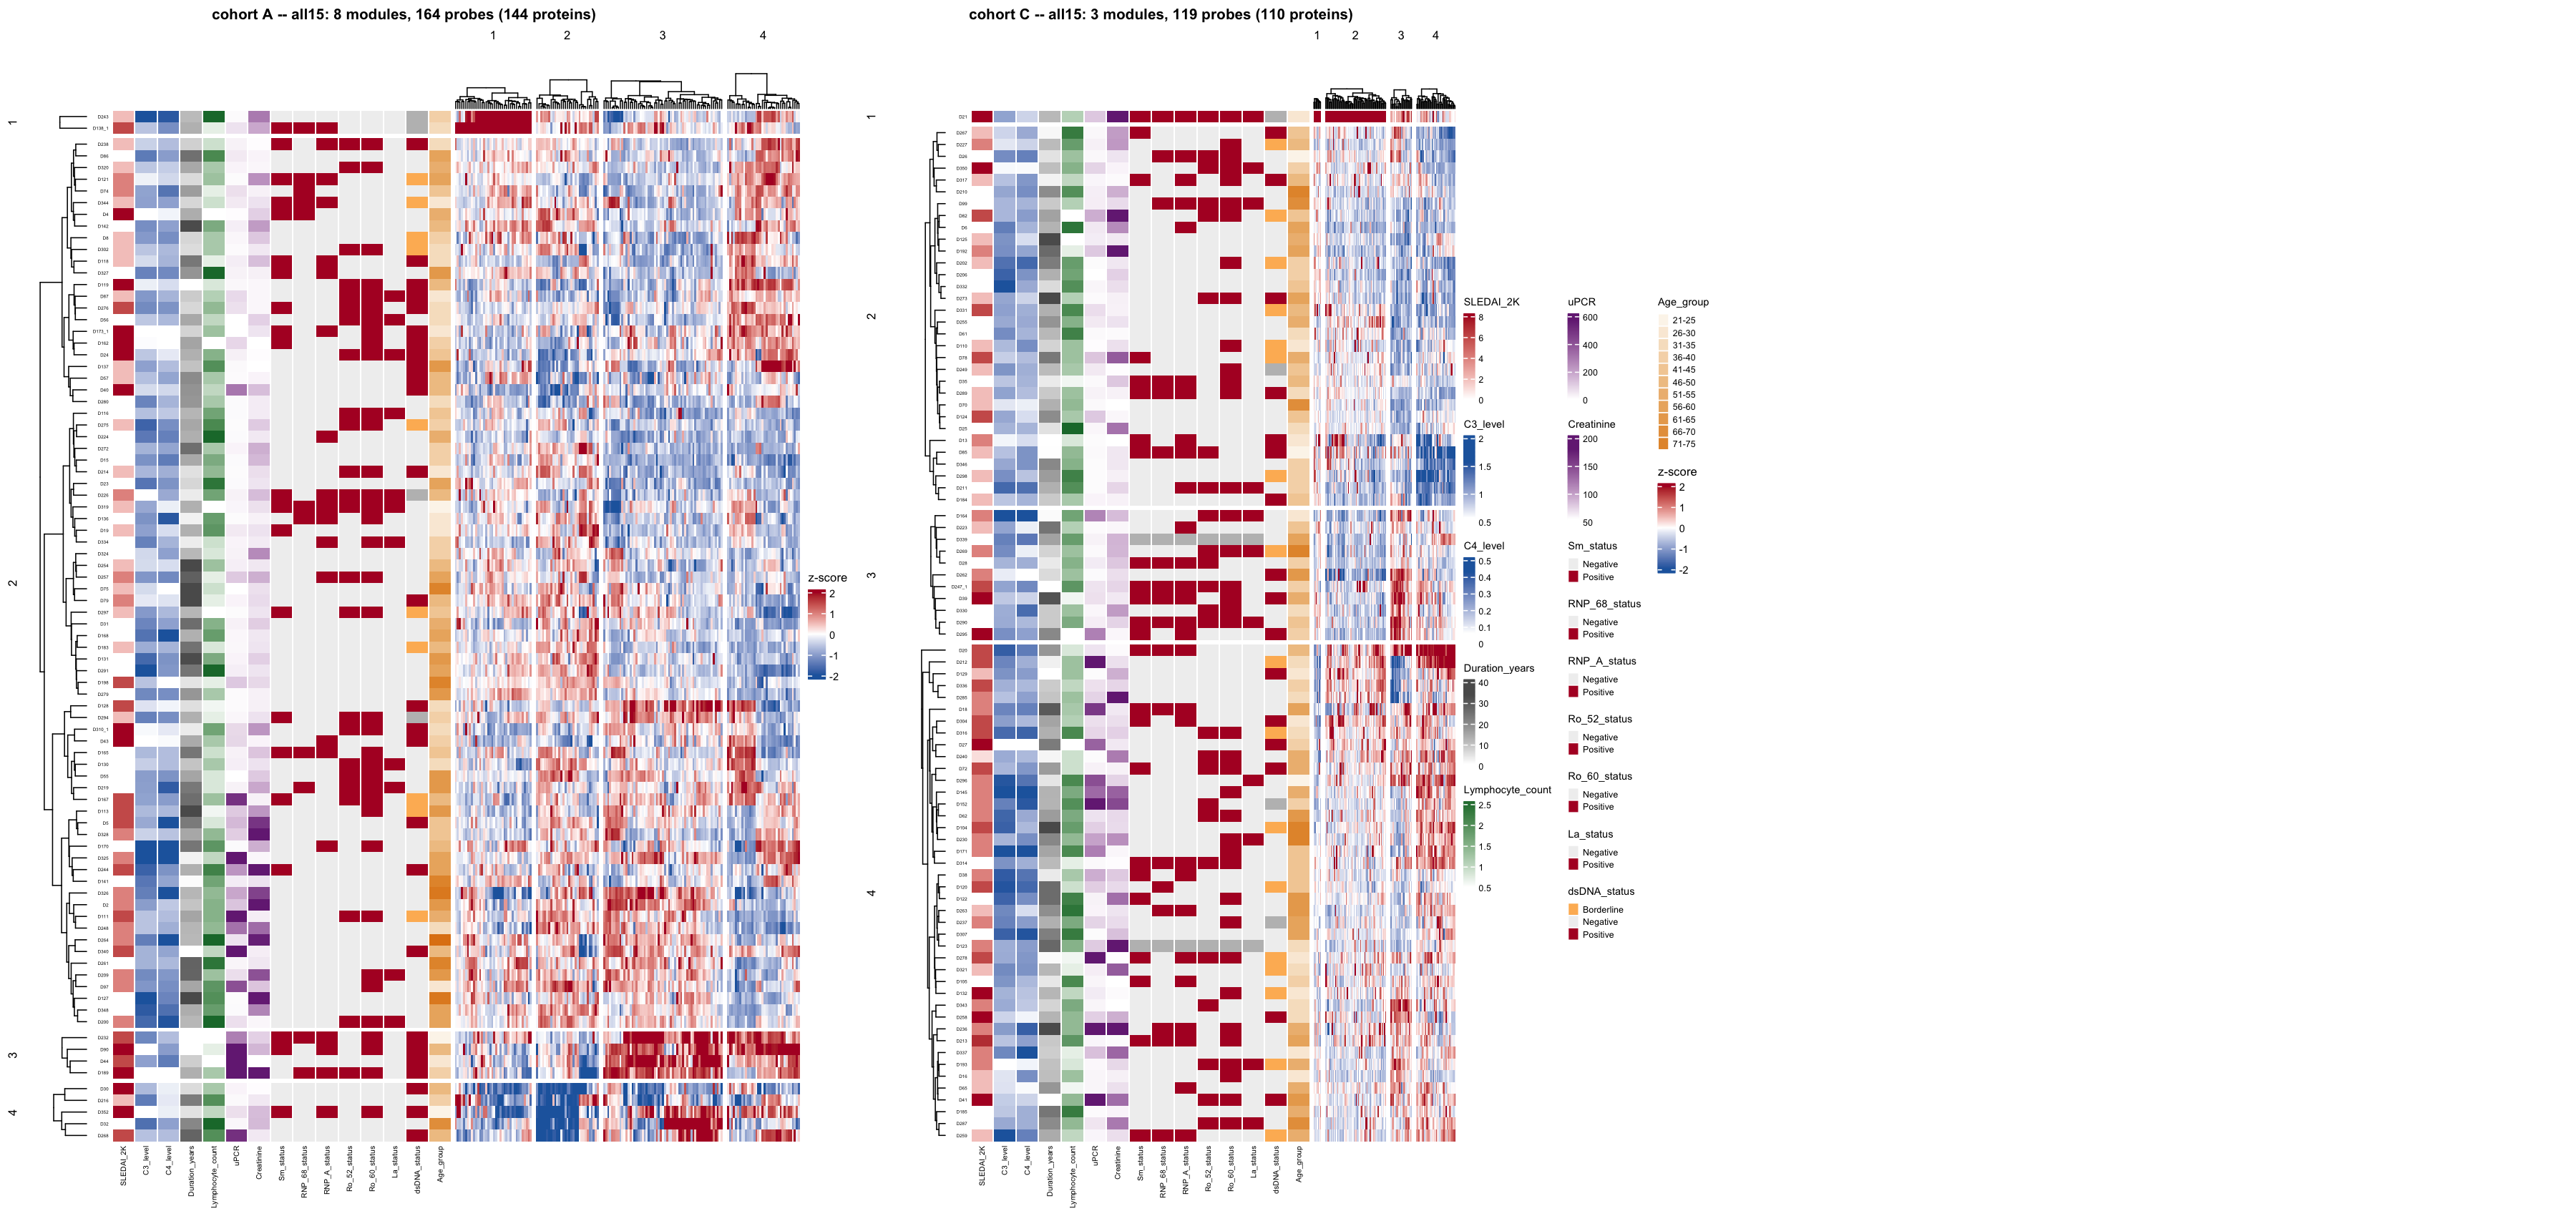

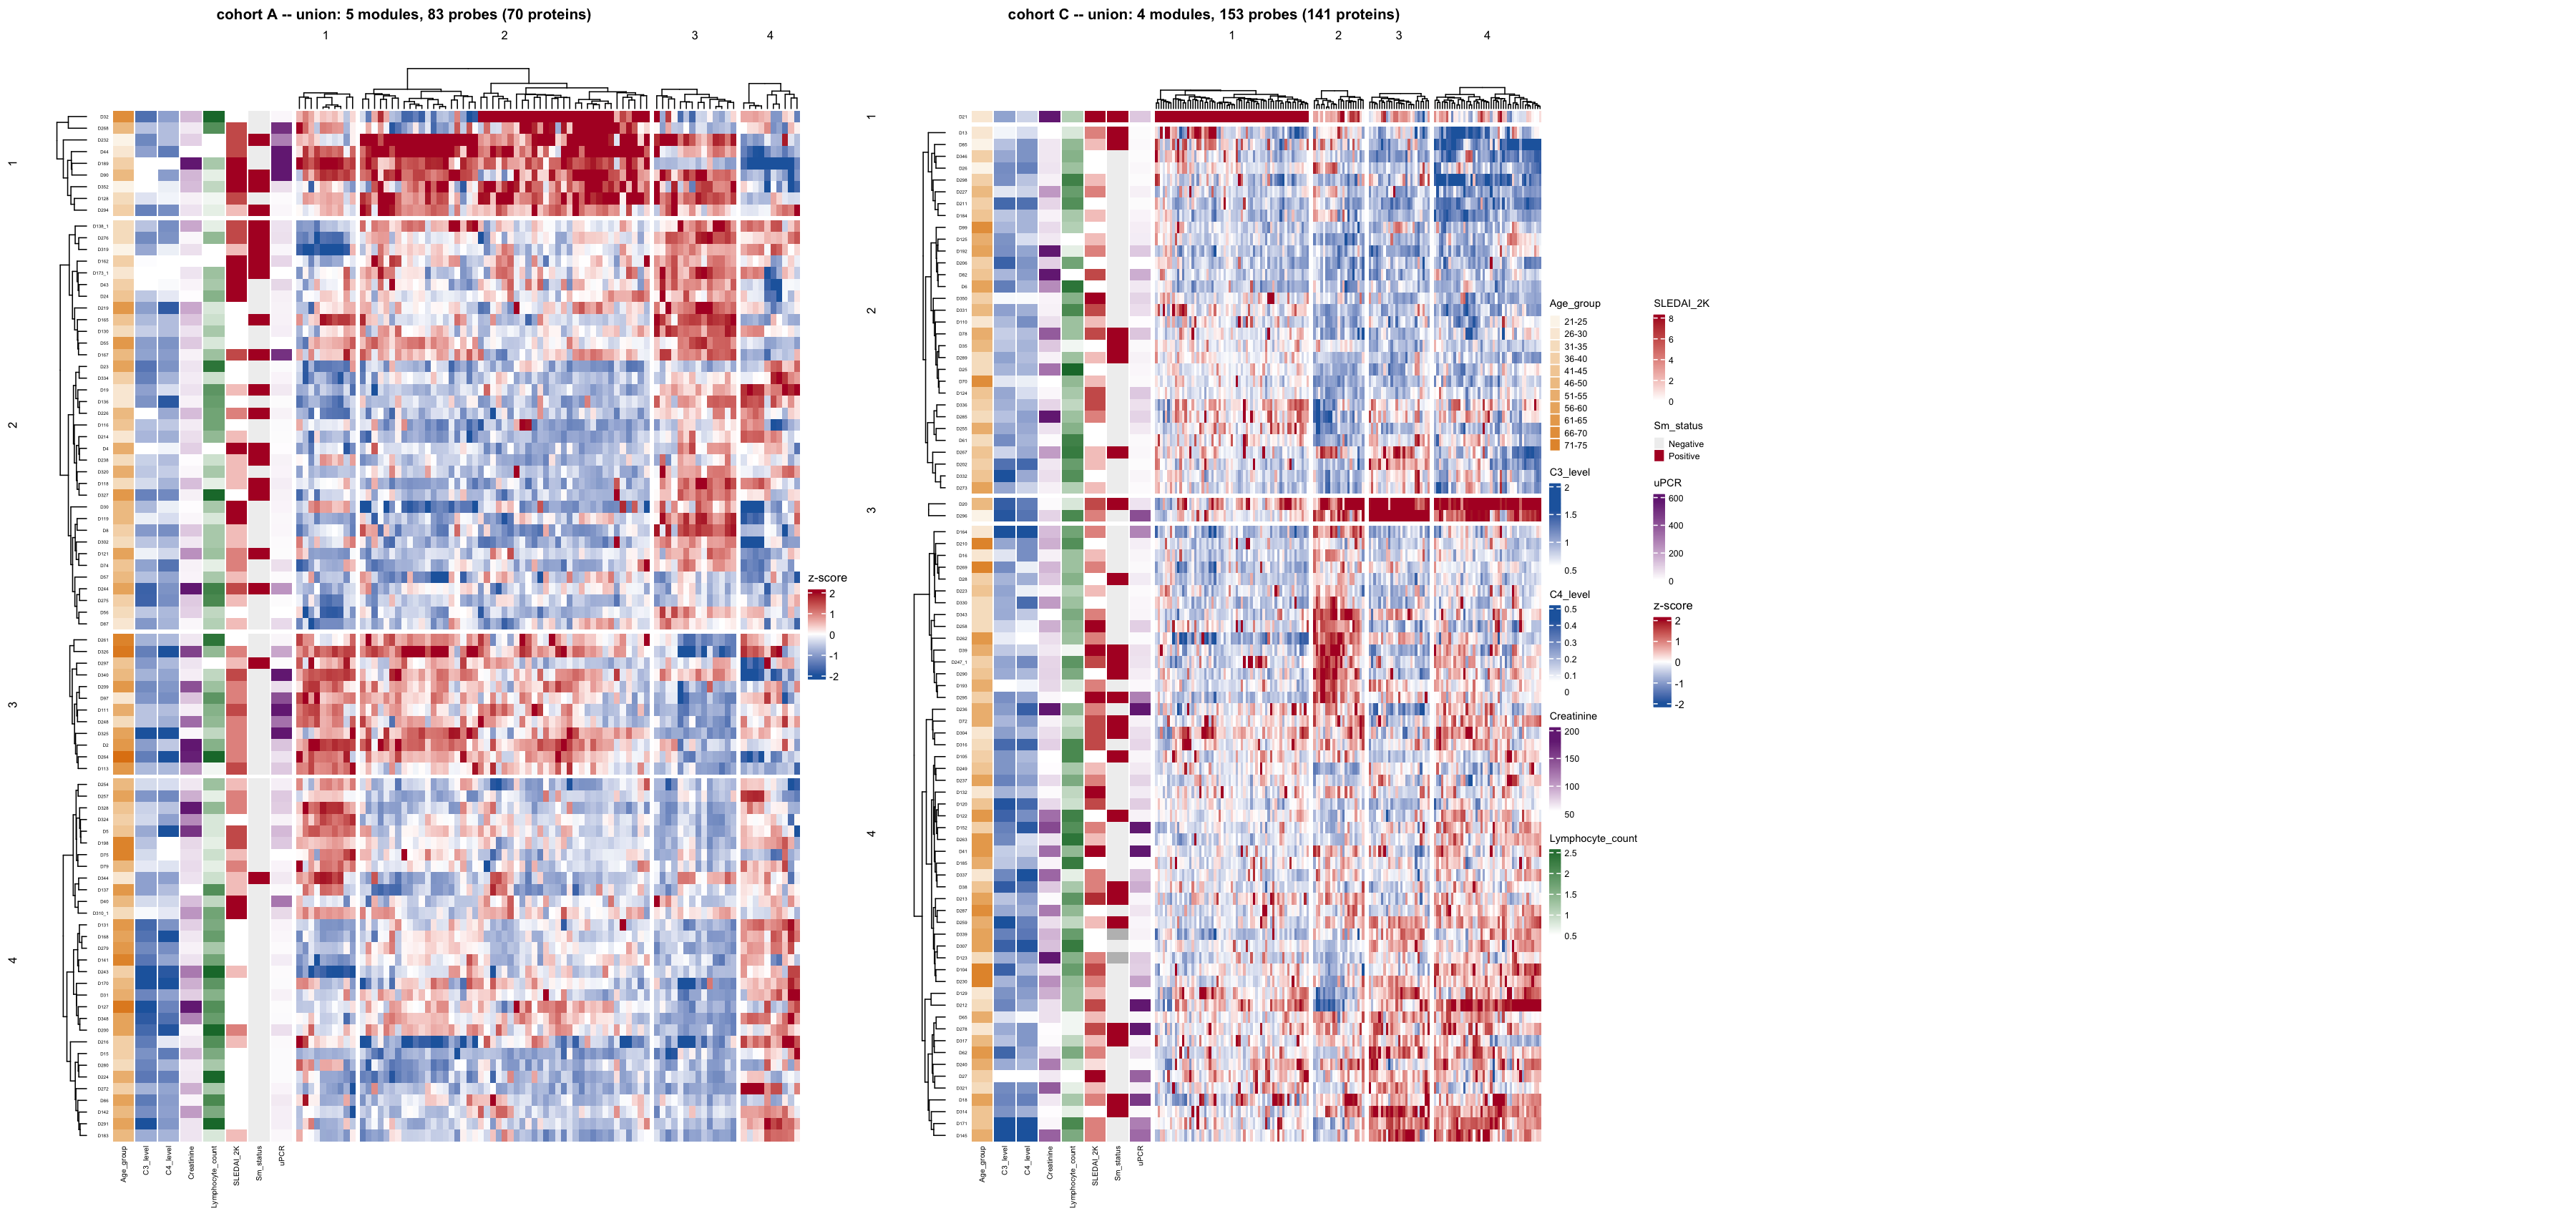

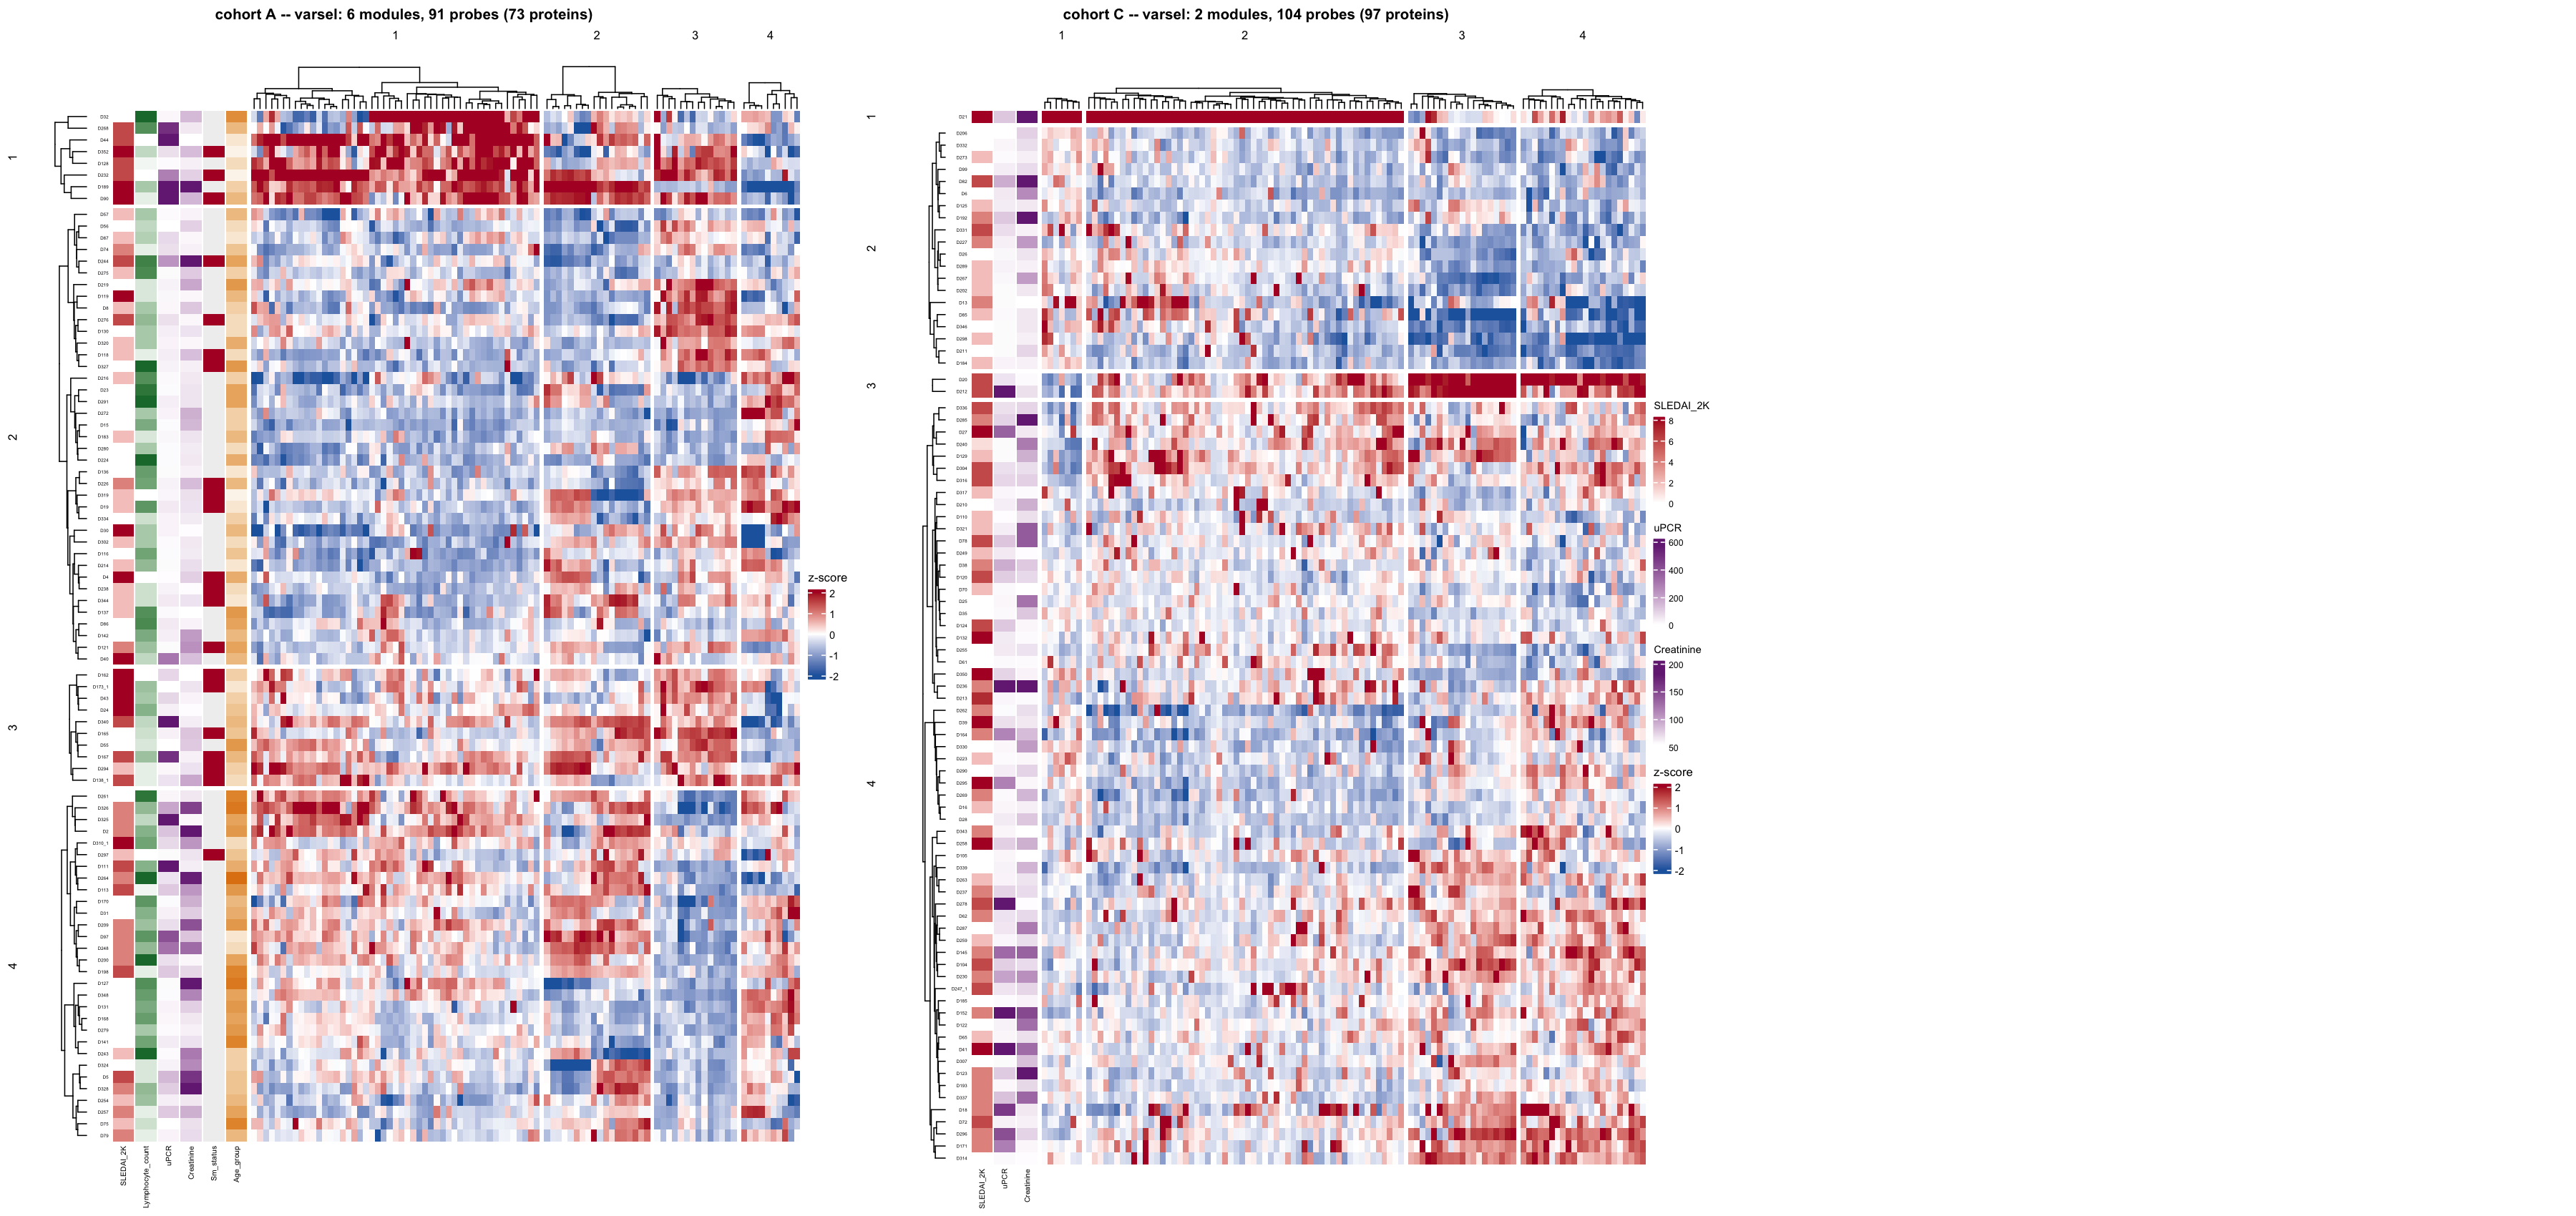

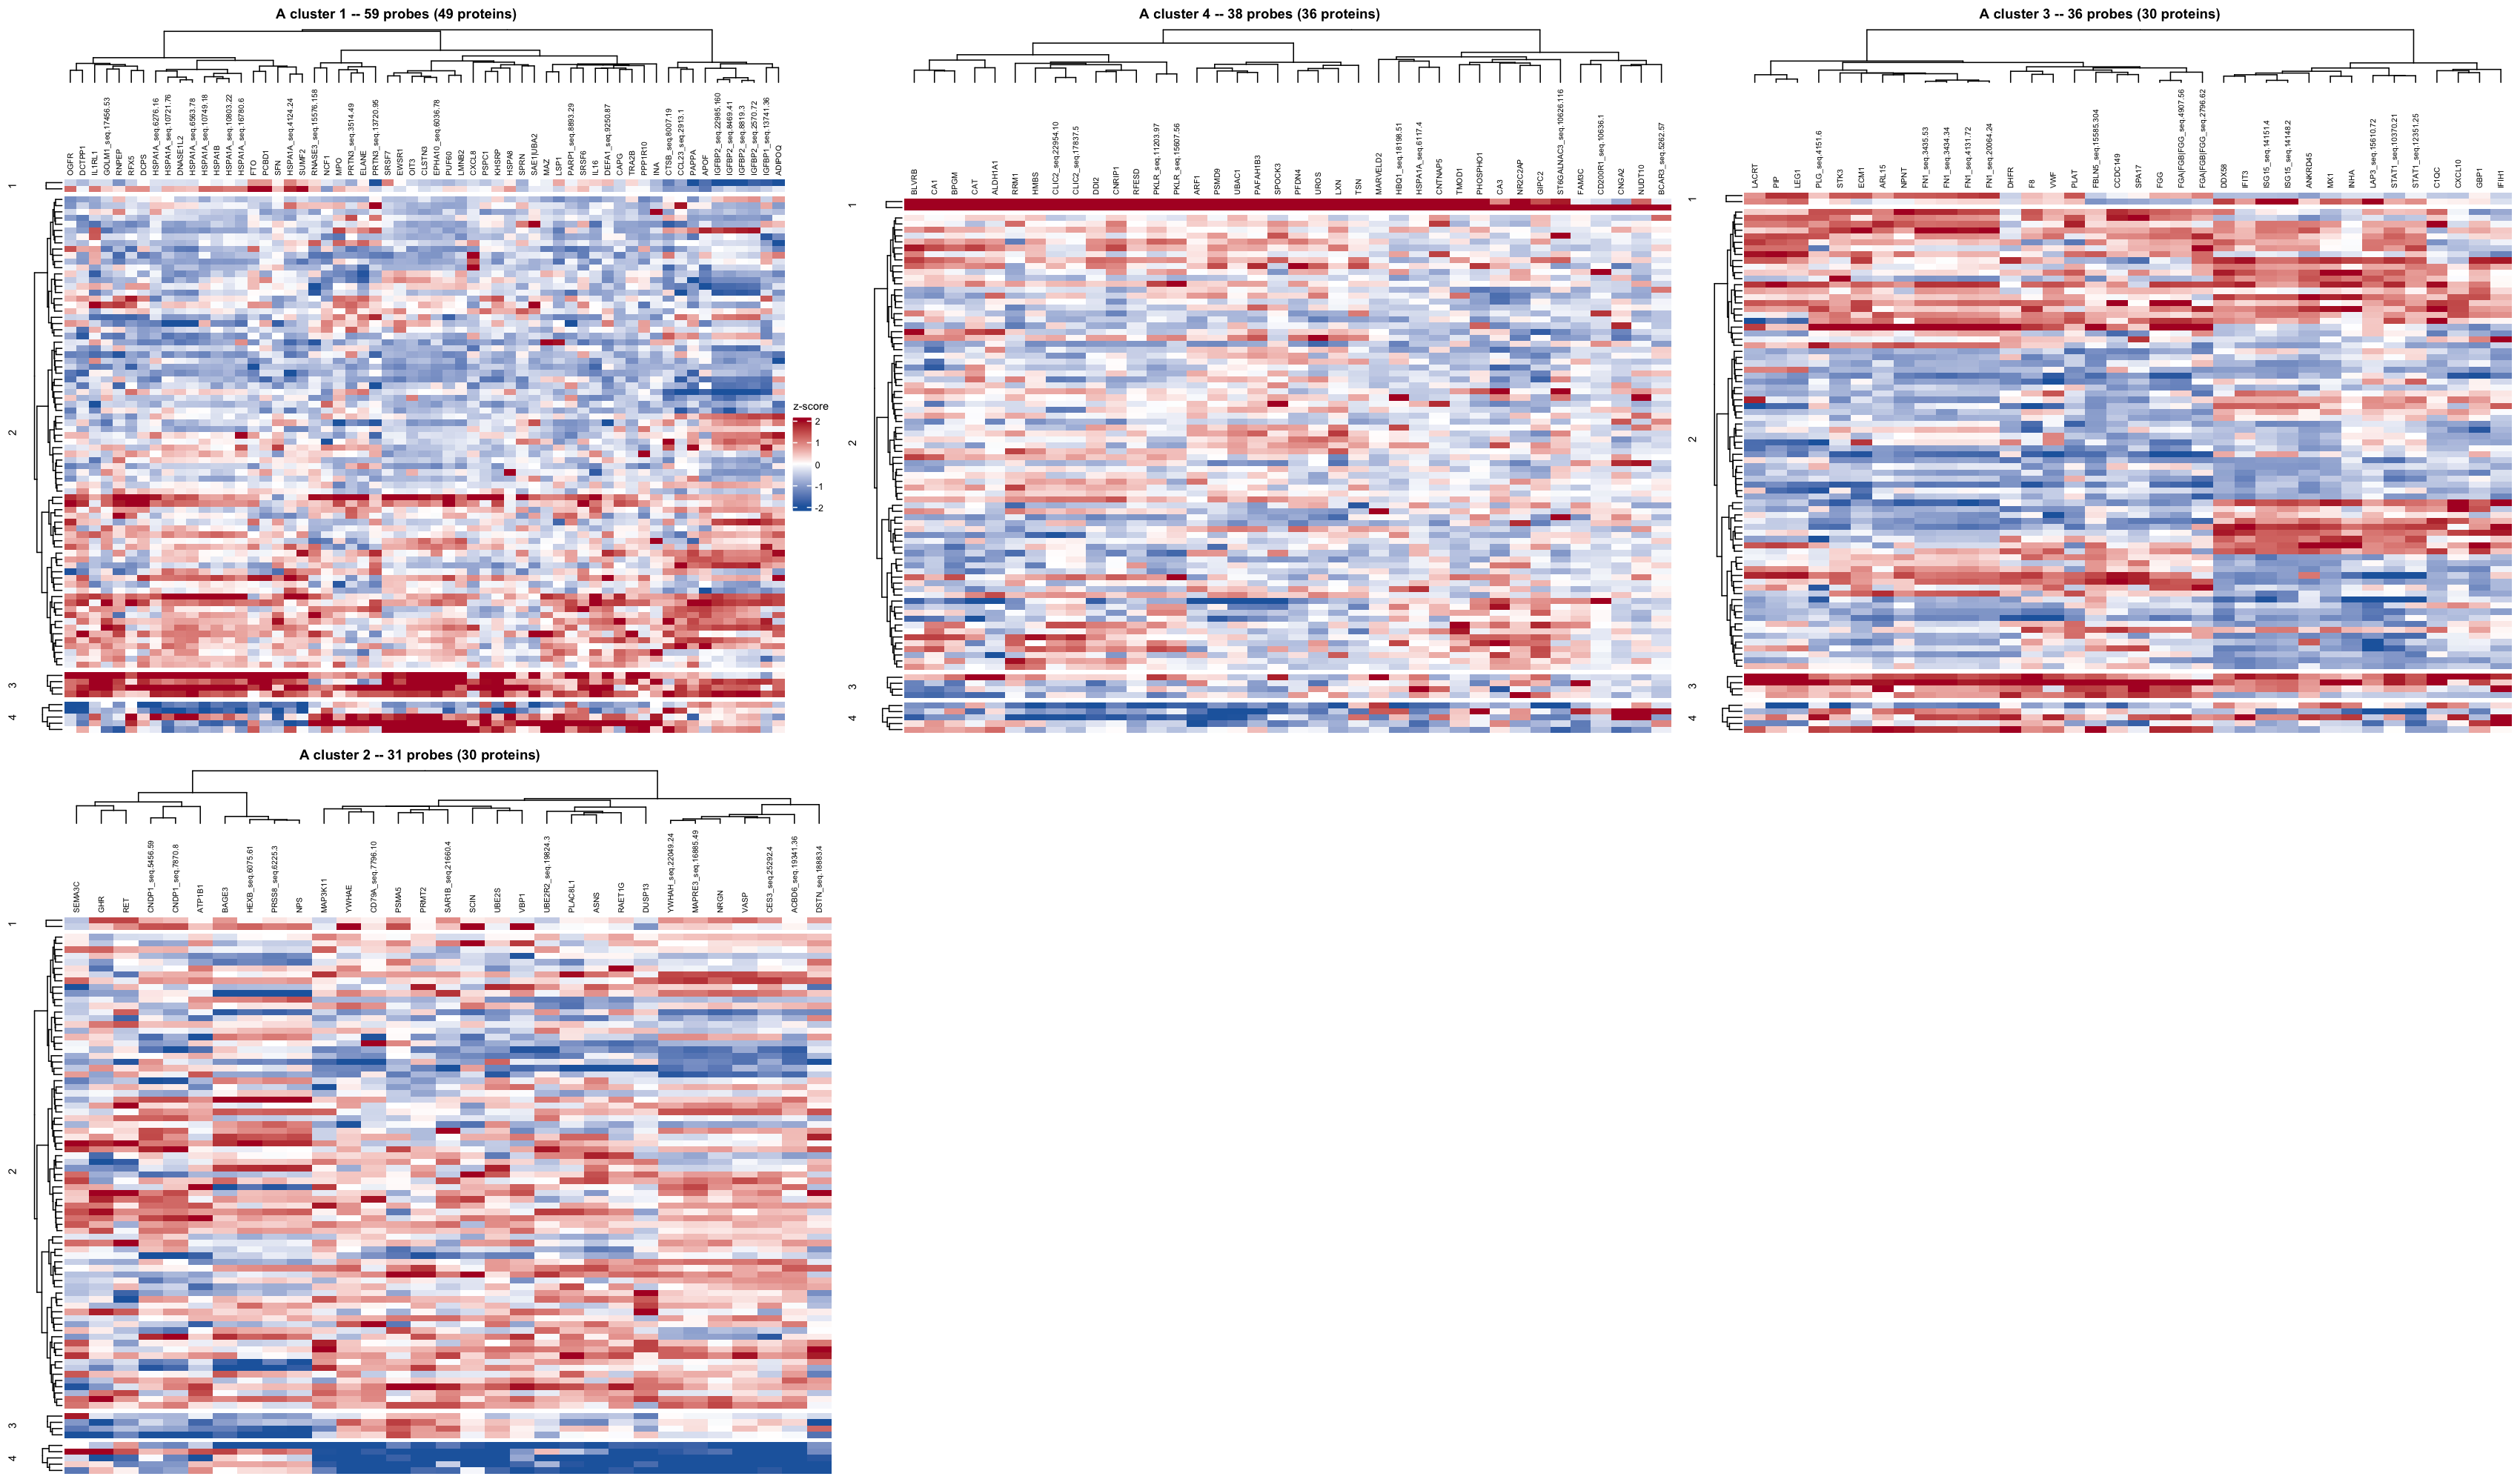

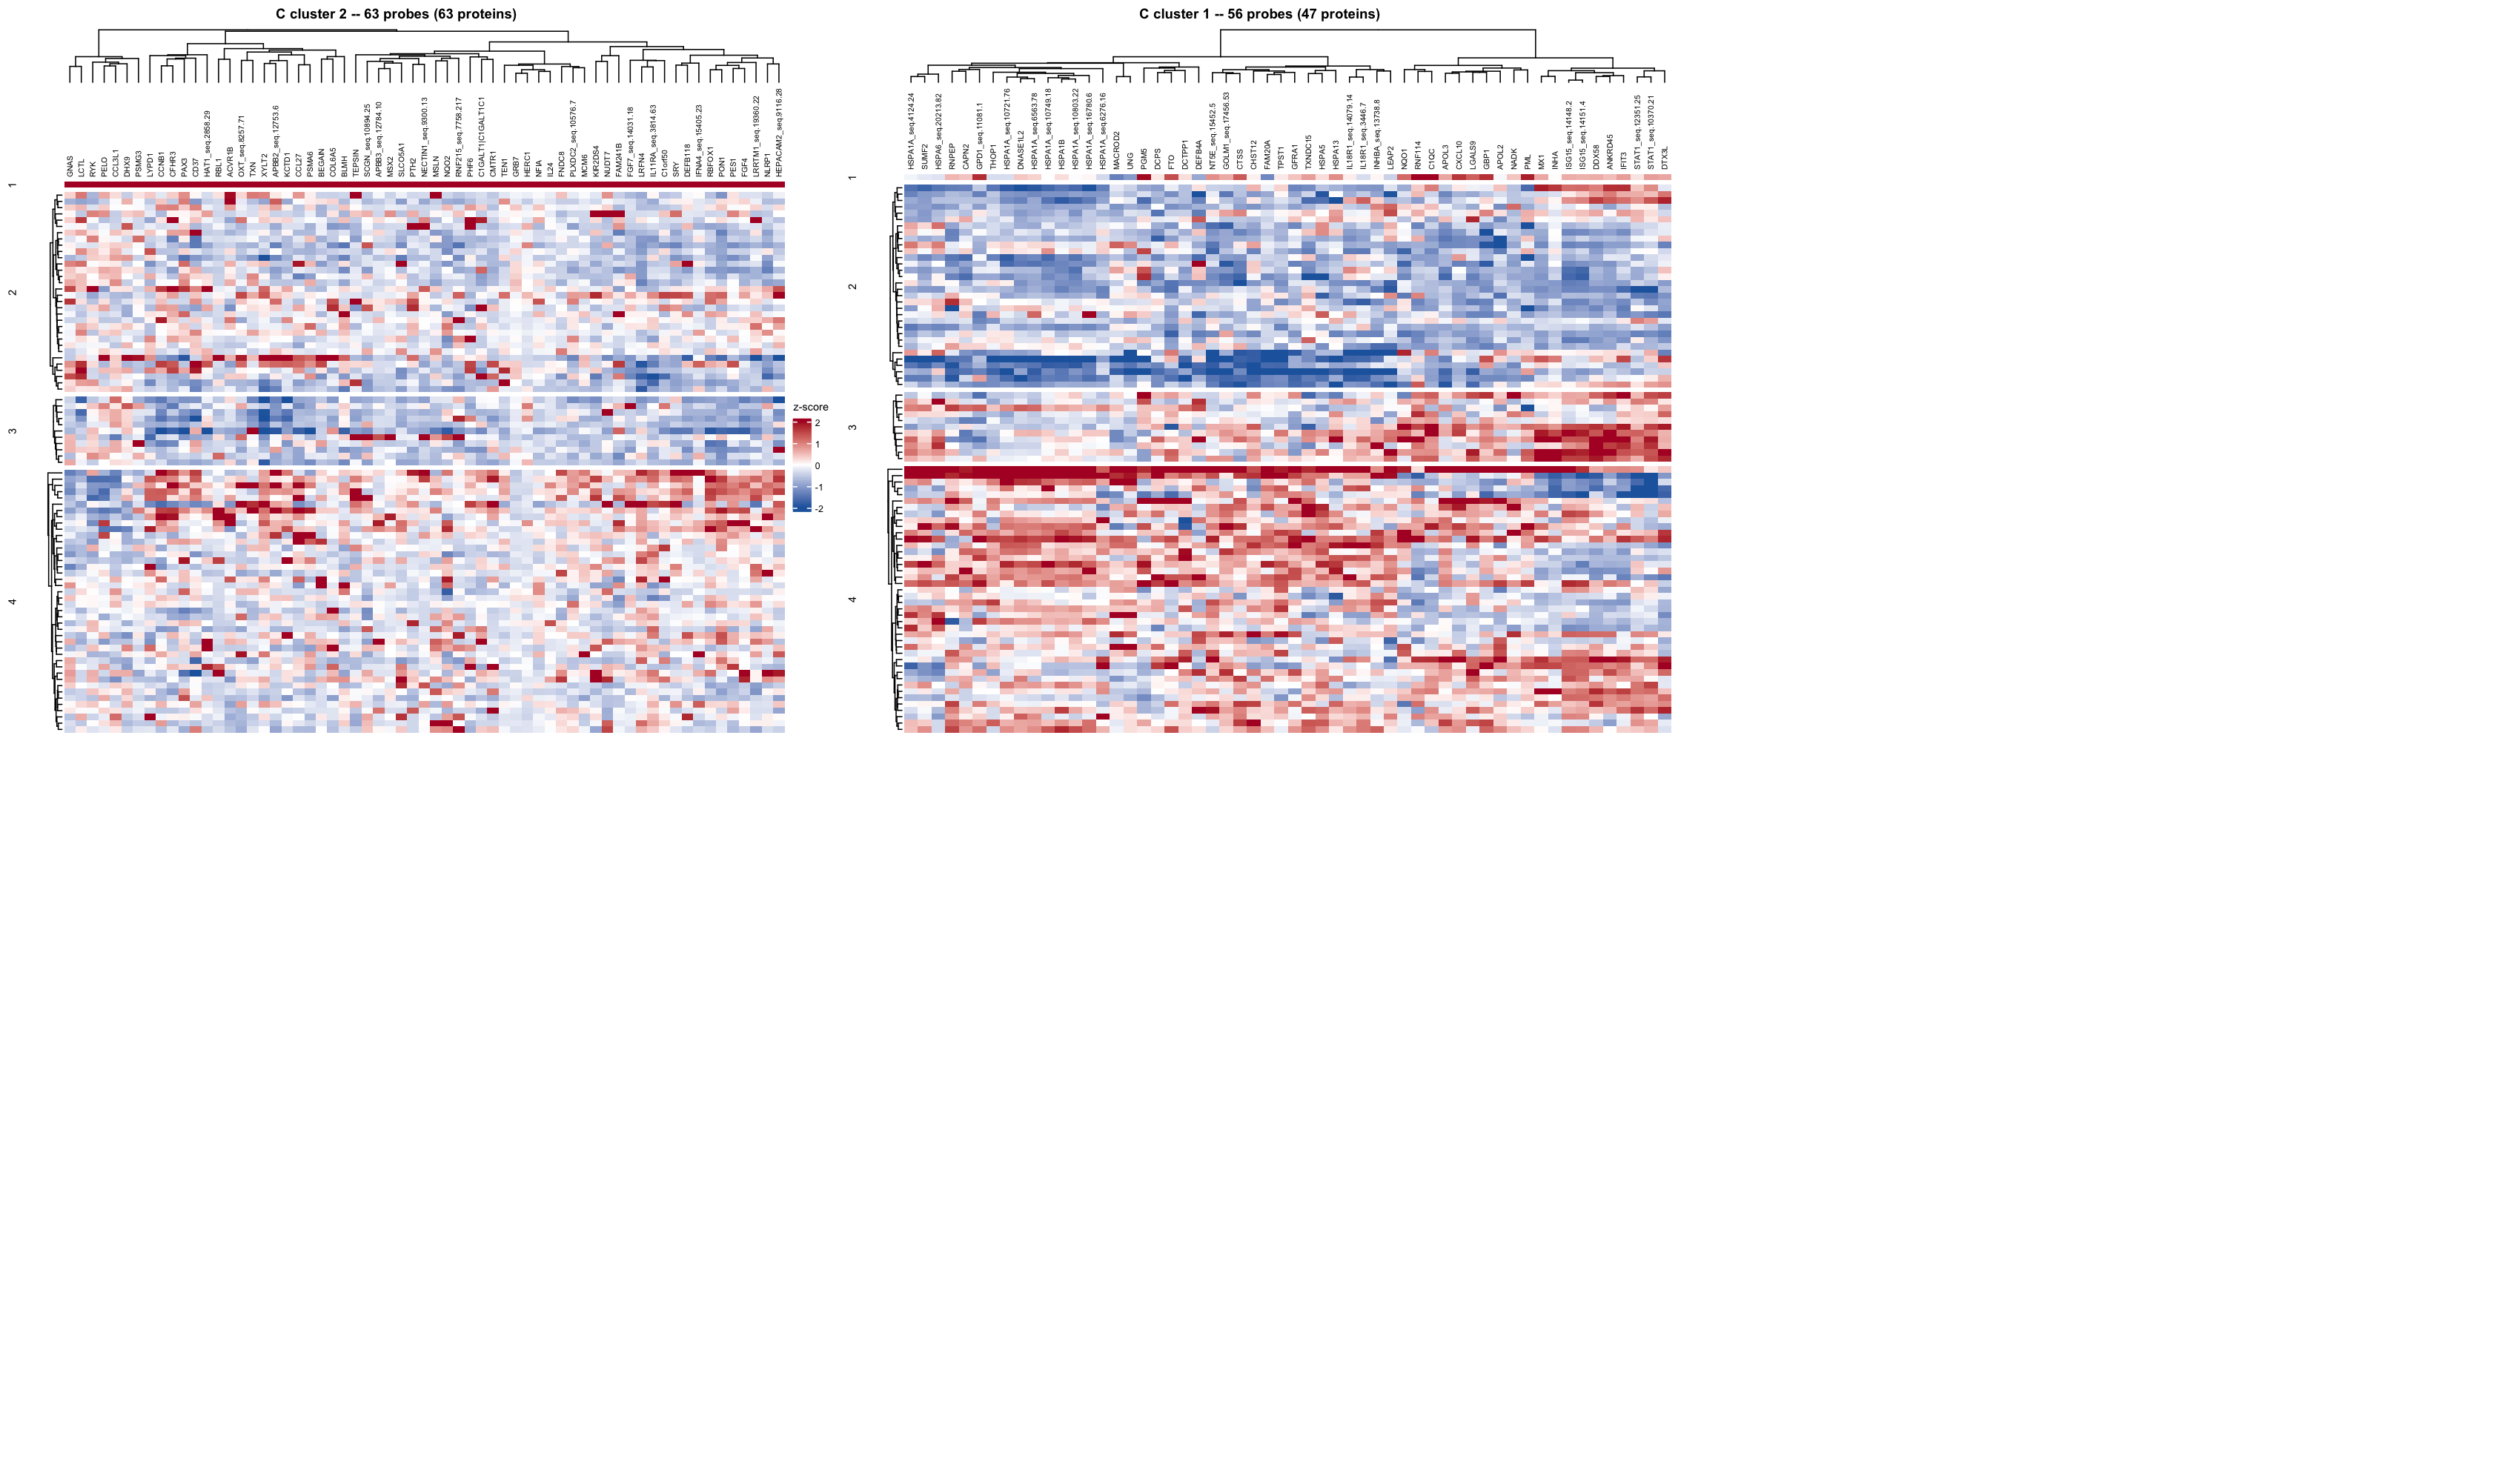

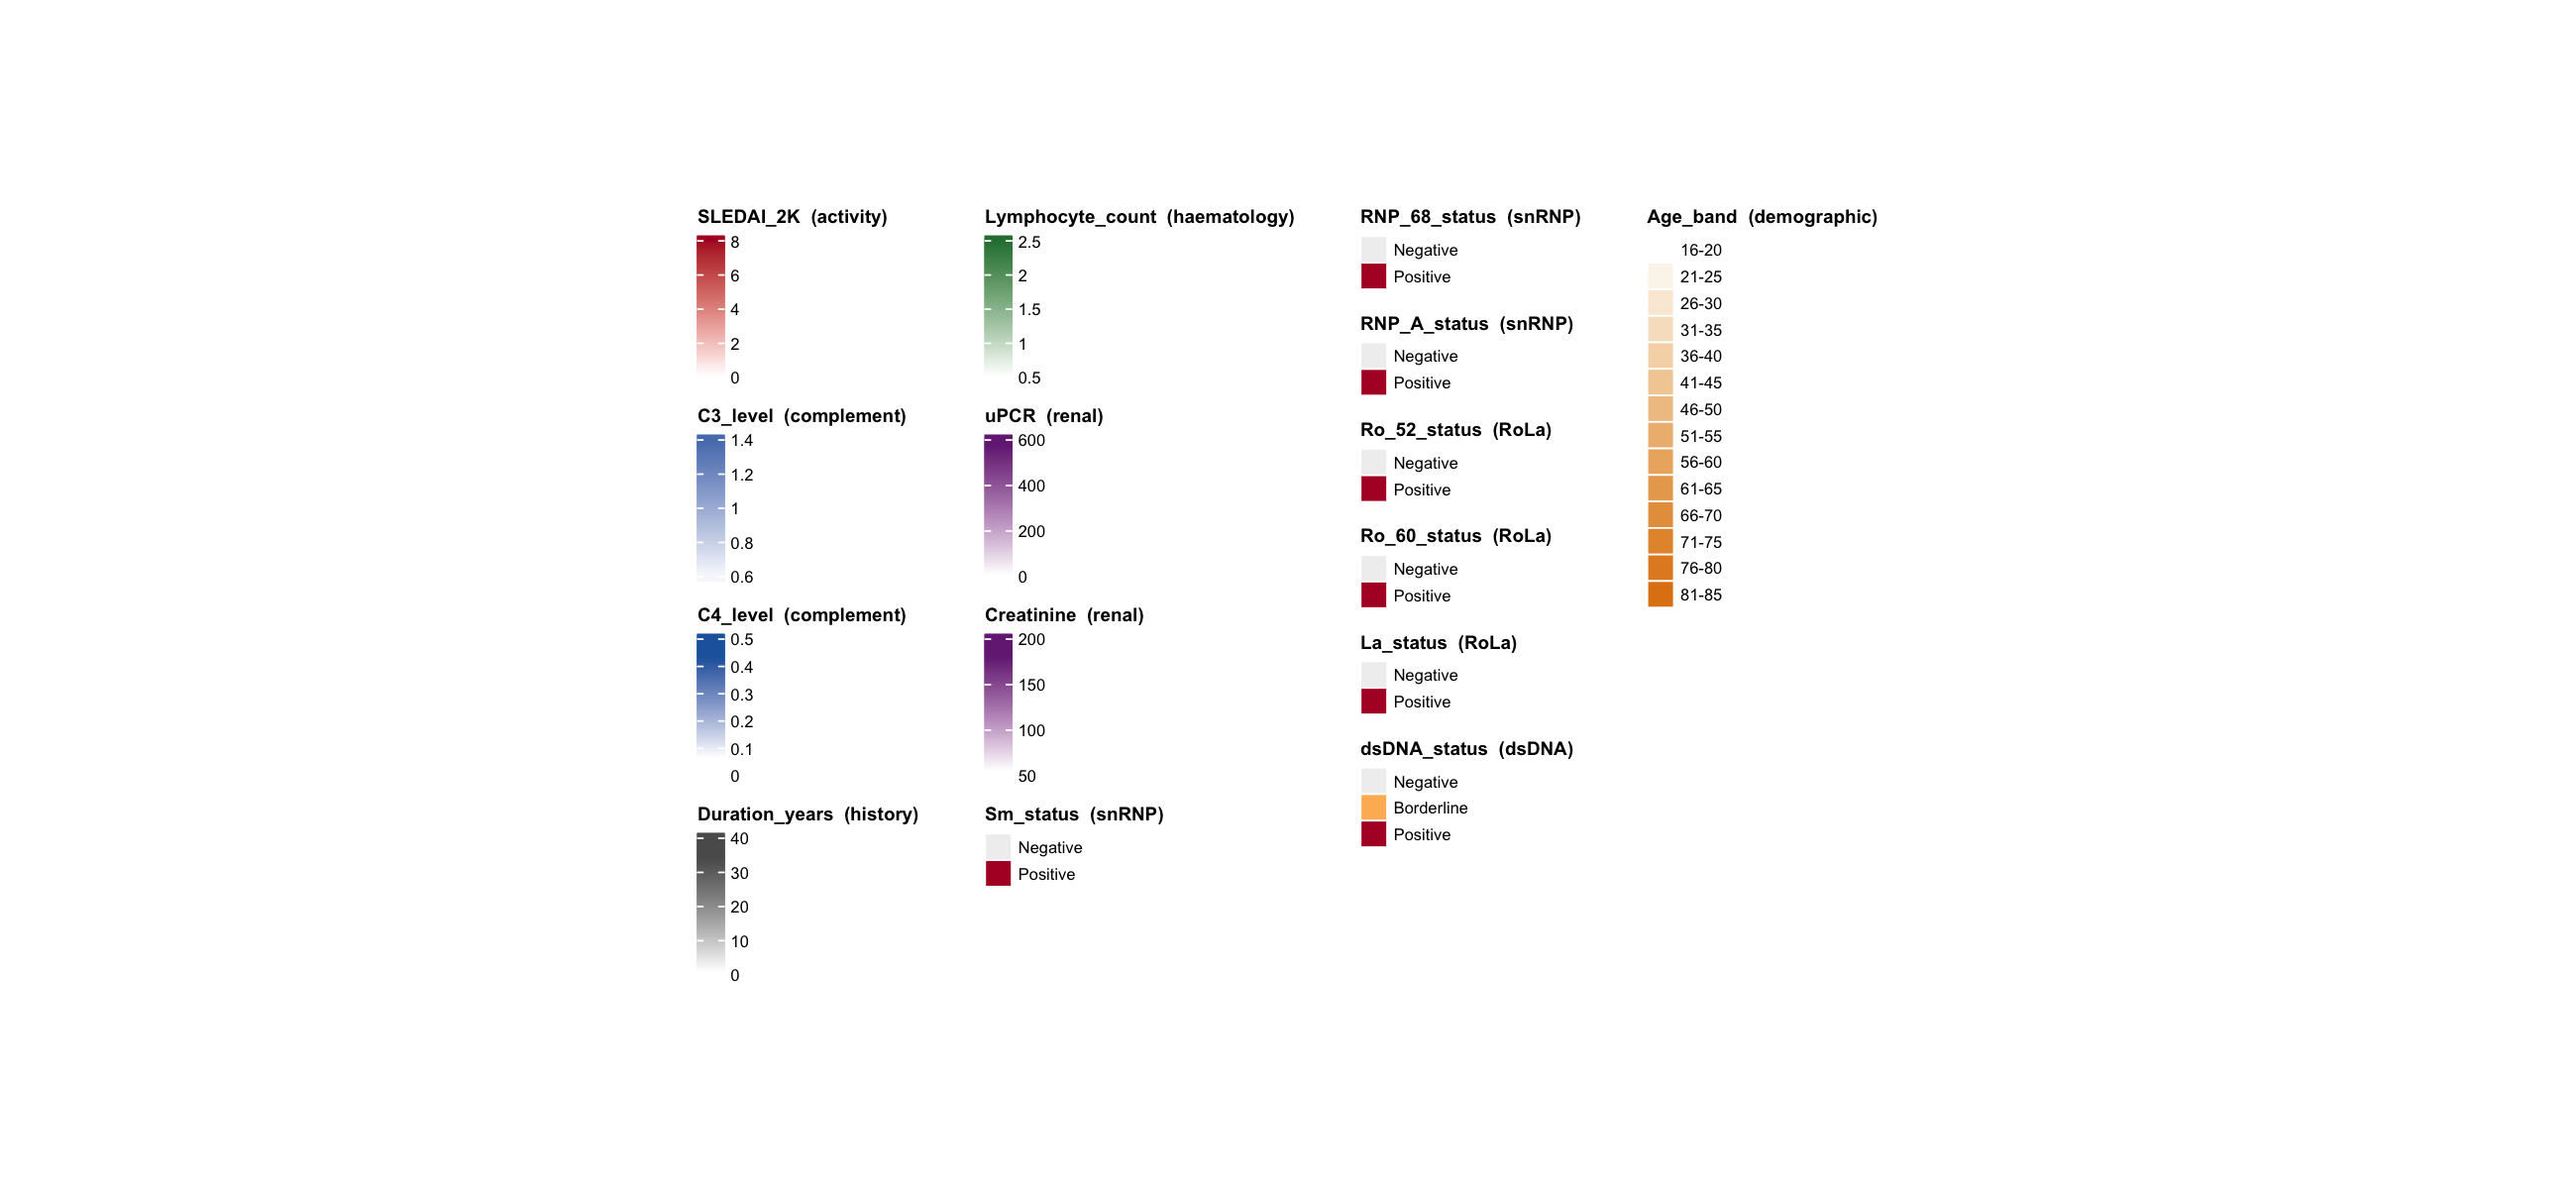

fig14_final_heatmap_A.png 
fig14_final_heatmap_C.png 
fig14_hclust_wardD2_minkowski_all15.png 
fig14_hclust_wardD2_minkowski_union.png 
fig14_hclust_wardD2_minkowski_varsel.png 
fig14_hclust_zoom_A.png 
fig14_hclust_zoom_C.png 
fig14_trait_legend.png 


In [3]:
show_figures("^fig14_.*\\.png$")

## Where this was run

Rendered notebooks are committed, so each records the machine, the R and the
package versions that produced its output.


In [4]:
run_provenance()

run on   : Annes-MacBook-Pro-193.local ( Darwin 27.0.0 )
date     : 2026-09-25 12:06 EDT 
R        : R version 4.4.3 (2025-02-28) | x86_64-apple-darwin13.4.0 
R comes from: /Users/adeslatt/miniforge3/envs/endotypes-proteomics 
packages :
   WGCNA            1.74
   ComplexHeatmap   2.22.0
   sva              3.54.0
   VarSelLCM        2.1.3.2
   cluster          2.1.8.1
   fpc              2.2.15
   circlize         0.4.18
